# Phase 2: Exploring the Data Pipeline

In this section, we verify our `DataLoader` works and visualise some of the images we are going to train on.

In [1]:
import sys
import matplotlib.pyplot as plt
import torch

# Add the parent directory to sys.path so we can import from src
sys.path.append('..')
from src.dataset import get_train_loader

# Load the train loader
# We pass the explicit path to the CSV file relative to this notebooks/ directory
train_loader = get_train_loader(csv_path='../data/digi_rec_train.csv')

In [2]:
# Grab one batch of images and labels from the loader
# We use iter() to create an iterator from the DataLoader, and next() to get the first batch.
images, labels = next(iter(train_loader))

print("--- Batch Information ---")
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

# The shape should be (64, 1, 28, 28) for images:
# 64 images per batch, 1 color channel (grayscale), 28 pixels high, 28 pixels wide.

--- Batch Information ---
Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])



--- Visualising 10 Samples ---


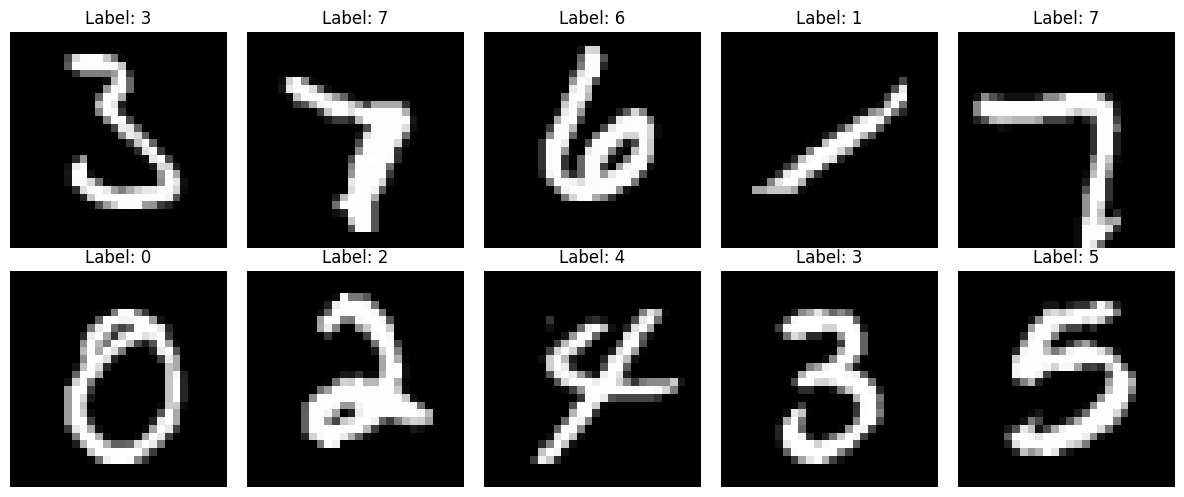

In [3]:
print("\n--- Visualising 10 Samples ---")

# Set up a matplotlib figure with 2 rows and 5 columns
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    # PyTorch tensors are in (Channel, Height, Width) format.
    # Matplotlib expects (Height, Width) for grayscale images.
    # We use .squeeze() to remove the channel dimension of 1 -> (28, 28)
    image_2d = images[i].squeeze().numpy()
    
    ax.imshow(image_2d, cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off') # Hide the axes ticks

plt.tight_layout()
plt.show()

---

# Phase 3: Model Architecture

Now we define our Convolutional Neural Network (CNN). A CNN is specially designed to process images by sliding small "filters" over the image to detect patterns like edges, curves, and eventually entire digits.

The network architecture we will build is:
1. **Conv Layer 1**: Detects basic patterns.
2. **Max Pool 1**: Shrinks the image size to save computation.
3. **Conv Layer 2**: Detects more complex shapes.
4. **Max Pool 2**: Shrinks the image again.
5. **Flatten & Dense Layer**: Converts the 2D spatial maps into a flat list of numbers to make a final classification.
6. **Dropout**: Randomly turns off some neurons to prevent the model from memorizing the data (overfitting).
7. **Output Layer**: 10 output numbers, one for each digit (0-9).

In [4]:
import torch.nn as nn
import torch.nn.functional as F
from src.model import DigitCNN

print("DigitCNN class imported successfully from src.model!")

DigitCNN class imported successfully from src.model!


### Testing the Model

Before we train, let's pass a "dummy" image through our model to ensure the dimensions align perfectly and the output shape is what we expect `(batch_size, 10)`.

In [5]:
# 1. Create an instance of our model
model = DigitCNN()

# 2. Create a dummy tensor that matches the shape of one image batch (1 image, 1 channel, 28x28)
dummy_input = torch.randn(1, 1, 28, 28)

# 3. Run a "forward pass" through the network
output = model(dummy_input)

print("--- Model Test ---")
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print("(Expected output shape is (1, 10) because we have 1 image and 10 possible digit classes)")

# 4. Calculate total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")
print("(For MNIST, a few hundred thousand parameters is typical and perfectly capable of >99% accuracy.)")

--- Model Test ---
Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])
(Expected output shape is (1, 10) because we have 1 image and 10 possible digit classes)

Total trainable parameters: 225,034
(For MNIST, a few hundred thousand parameters is typical and perfectly capable of >99% accuracy.)


---

# Phase 4: The Training Loop

Now we write the loop that actually teaches our model. It will:
1. Take a batch of images and make predictions (Forward Pass).
2. Calculate how wrong the predictions were using **CrossEntropyLoss**.
3. Figure out how to adjust the weights to be less wrong next time using **Backpropagation**.
4. Actually adjust the weights using the **Adam Optimizer**.
5. Check its accuracy on the unseen validation set.
6. Save the model weights if the accuracy improved.

In [6]:
from src.dataset import get_dataloaders
import torch.optim as optim
import os

# --- Training Hyperparameters ---
LEARNING_RATE = 0.001   # How big of a step to take when adjusting weights. Too high = erratic, too low = slow.
EPOCHS = 10             # How many times to loop over the ENTIRE training dataset.
MODEL_SAVE_PATH = "../model/digit_cnn.pth"

# Ensure the model directory exists
os.makedirs("../model", exist_ok=True)

# 1. Load Data
print("Loading data...")
train_loader, val_loader = get_dataloaders(csv_path='../data/digi_rec_train.csv', batch_size=64)

# 2. Initialize Model, Loss, and Optimizer
model = DigitCNN()

# CrossEntropyLoss is the standard for classification. It pushes the score of the correct class up, and incorrect classes down.
criterion = nn.CrossEntropyLoss()

# Adam is a smart optimizer. It tracks the history of our weight updates and adapts the learning rate per parameter automatically.
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_acc = 0.0

print("Starting training...\n")
for epoch in range(1, EPOCHS + 1):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode (enables Dropout)
    running_loss = 0.0
    
    for images, labels in train_loader:
        # 1. Zero out old gradients (PyTorch accumulates them by default)
        optimizer.zero_grad()
        
        # 2. Forward pass: get predictions
        outputs = model(images)
        
        # 3. Calculate the loss (how wrong we are)
        loss = criterion(outputs, labels)
        
        # 4. Backward pass: calculate the gradients (loss flows backwards through the network)
        loss.backward()
        
        # 5. Optimize: step the weights in the correct direction
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables Dropout)
    correct = 0
    total = 0
    
    # torch.no_grad() tells PyTorch we don't need to track gradients here. Saves memory and speeds things up.
    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_outputs = model(val_images)
            
            # Get the predicted class (the index with the highest score)
            _, predicted = torch.max(val_outputs.data, 1)
            
            total += val_labels.size(0)
            correct += (predicted == val_labels).sum().item()
            
    val_acc = 100.0 * correct / total
    
    # Print stats
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # --- SAVE BEST MODEL ---
    # We only save if the model actually improved on the validation set. 
    # This prevents us from saving an overfitted model in the later epochs.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"   --> Model improved! Saved to {MODEL_SAVE_PATH}")

print("\nTraining complete!")

Loading data...


Starting training...



Epoch  1/10 | Train Loss: 0.2976 | Val Acc: 97.58%
   --> Model improved! Saved to ../model/digit_cnn.pth


Epoch  2/10 | Train Loss: 0.1014 | Val Acc: 98.21%
   --> Model improved! Saved to ../model/digit_cnn.pth


Epoch  3/10 | Train Loss: 0.0758 | Val Acc: 98.35%
   --> Model improved! Saved to ../model/digit_cnn.pth


...

Epoch  6/10 | Train Loss: 0.0426 | Val Acc: 98.73%
   --> Model improved! Saved to ../model/digit_cnn.pth


Epoch  7/10 | Train Loss: 0.0381 | Val Acc: 98.57%


Epoch  8/10 | Train Loss: 0.0324 | Val Acc: 98.80%
   --> Model improved! Saved to ../model/digit_cnn.pth


Epoch  9/10 | Train Loss: 0.0303 | Val Acc: 98.82%
   --> Model improved! Saved to ../model/digit_cnn.pth


Epoch 10/10 | Train Loss: 0.0268 | Val Acc: 98.87%
   --> Model improved! Saved to ../model/digit_cnn.pth

Training complete!


---

## What do the conv layers see?

Let's look inside the "brain" of the CNN. We will take a single digit and pass it through the first two convolutional layers.

We will compare **Untrained Weights** (random static) vs **Trained Weights** (after the training loop above).
Notice how the untrained weights produce random noise, while the trained weights actively highlight edges, corners, shapes, and empty space!

Loaded trained weights successfully!

Visualising the original image...


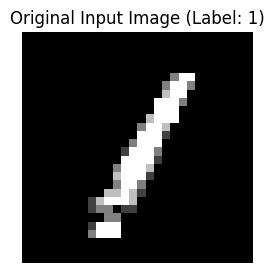

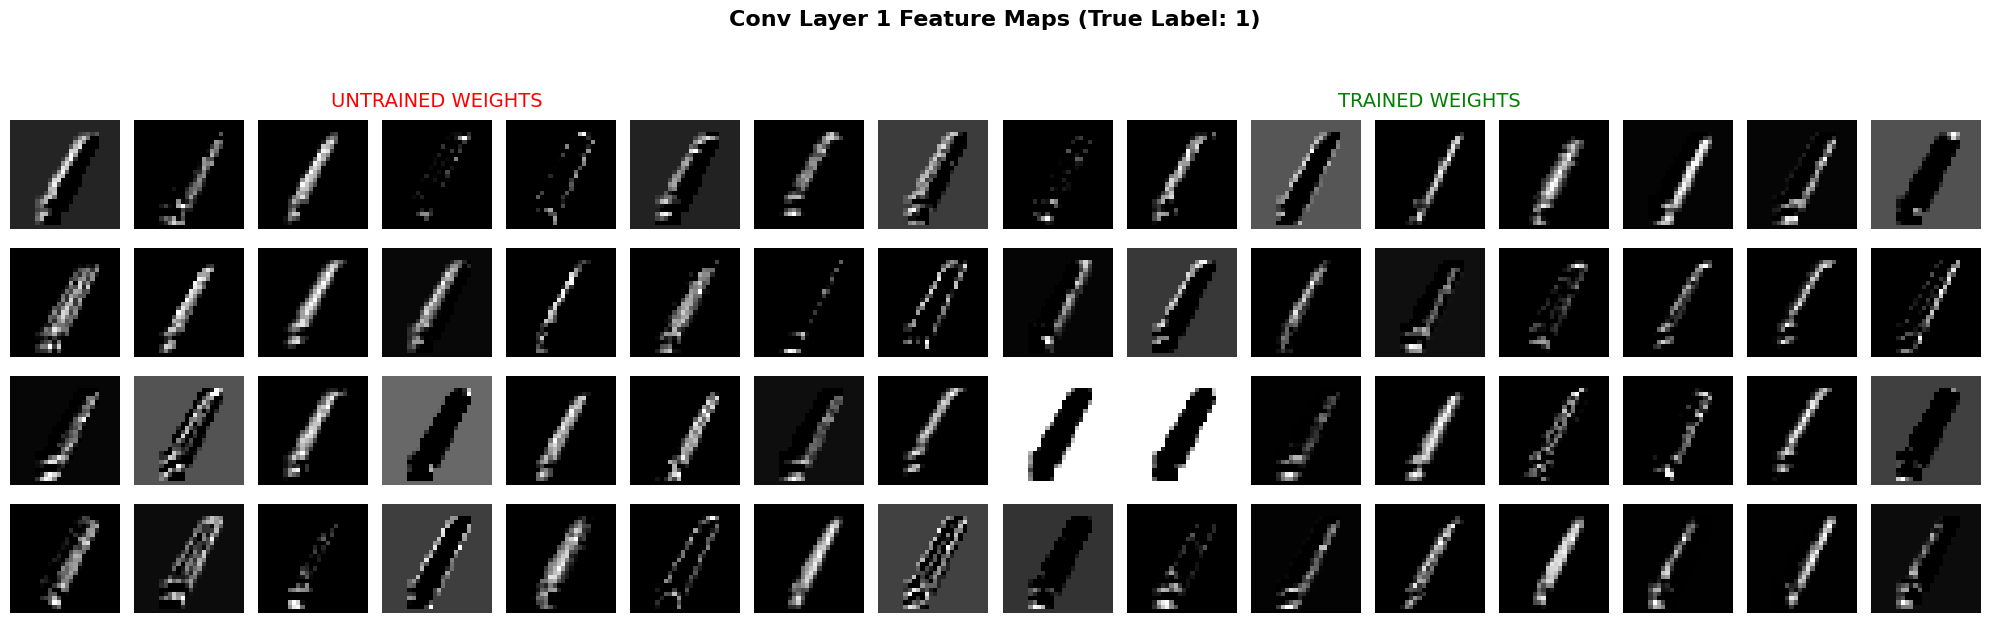

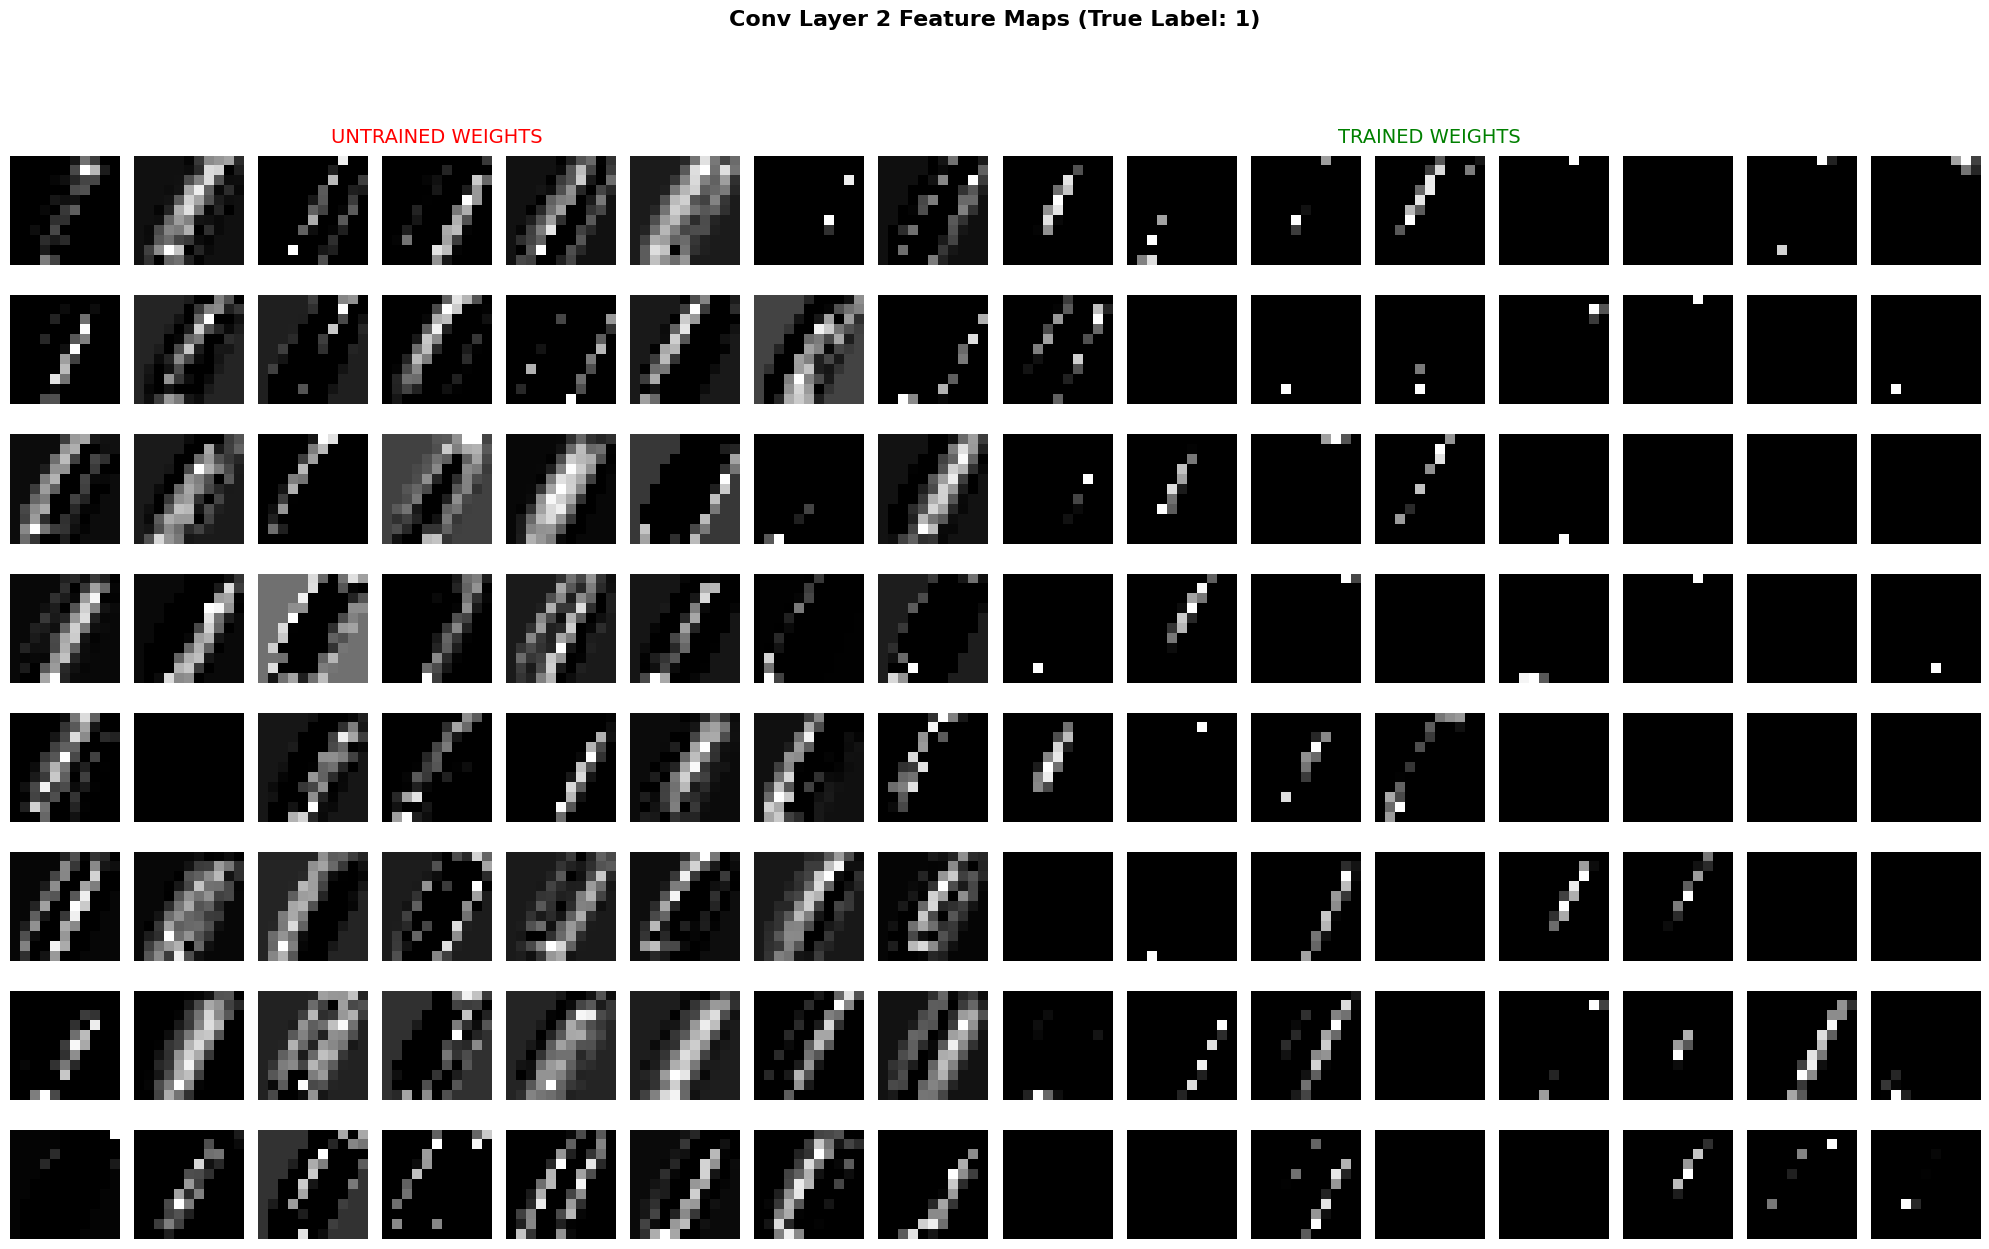

In [7]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import os

# 1. Initialize two models
untrained_model = DigitCNN()
untrained_model.eval()

trained_model = DigitCNN()
try:
    trained_model.load_state_dict(torch.load("../model/digit_cnn.pth", map_location=torch.device('cpu')))
    trained_model.eval()
    print("Loaded trained weights successfully!")
except FileNotFoundError:
    print("WARNING: ../model/digit_cnn.pth not found. Did you run the training loop above? Falling back to untrained for both.")
    trained_model = untrained_model

# 2. Grab a single sample image from the validation set
images, labels = next(iter(val_loader))
sample_image = images[0:1] # Keep the batch dimension: shape (1, 1, 28, 28)
sample_label = labels[0].item()

# 3. Function to extract feature maps
def get_feature_maps(model, x):
    with torch.no_grad():
        # Pass through Conv1 and ReLU
        map1 = F.relu(model.conv1(x))
        # Pass through Pool1
        x_pool = F.max_pool2d(map1, 2)
        # Pass through Conv2 and ReLU
        map2 = F.relu(model.conv2(x_pool))
    return map1.squeeze(0), map2.squeeze(0) # Remove batch dimension for plotting

untrained_map1, untrained_map2 = get_feature_maps(untrained_model, sample_image)
trained_map1, trained_map2 = get_feature_maps(trained_model, sample_image)

# 4. Helper function to plot side-by-side grids
def plot_feature_maps(fmaps_un, fmaps_tr, title, num_maps):
    cols = 8
    rows = num_maps // cols
    
    # We make the figure wide enough to hold two side-by-side grids
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 2.5, rows * 1.5))
    fig.suptitle(f"{title} (True Label: {sample_label})", fontsize=16, fontweight='bold', y=1.05)
    
    for i in range(num_maps):
        r = i // cols
        c_un = i % cols
        c_tr = c_un + cols
        
        # Plot Untrained
        ax_un = axes[r, c_un]
        ax_un.imshow(fmaps_un[i].numpy(), cmap='gray')
        ax_un.axis('off')
        
        # Plot Trained
        ax_tr = axes[r, c_tr]
        ax_tr.imshow(fmaps_tr[i].numpy(), cmap='gray')
        ax_tr.axis('off')
        
        # Top row titles
        if r == 0 and c_un == 3:
            ax_un.set_title("UNTRAINED WEIGHTS", fontsize=14, pad=10, color='red')
        if r == 0 and c_tr == 3 + cols:
            ax_tr.set_title("TRAINED WEIGHTS", fontsize=14, pad=10, color='green')

    plt.tight_layout()
    plt.show()

print("\nVisualising the original image...")
plt.figure(figsize=(3,3))
plt.imshow(sample_image.squeeze().numpy(), cmap='gray')
plt.title(f"Original Input Image (Label: {sample_label})")
plt.axis('off')
plt.show()

# 5. Plot Conv Layer 1 (32 maps)
plot_feature_maps(untrained_map1, trained_map1, "Conv Layer 1 Feature Maps", 32)

# 6. Plot Conv Layer 2 (64 maps)
plot_feature_maps(untrained_map2, trained_map2, "Conv Layer 2 Feature Maps", 64)


--- Batch Information ---
Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


---

# Phase 5: Evaluation & Confusion Matrix

Let's evaluate the model on the validation set, generate a confusion matrix to see which digits get confused with which, and look at the images the model gets completely wrong.

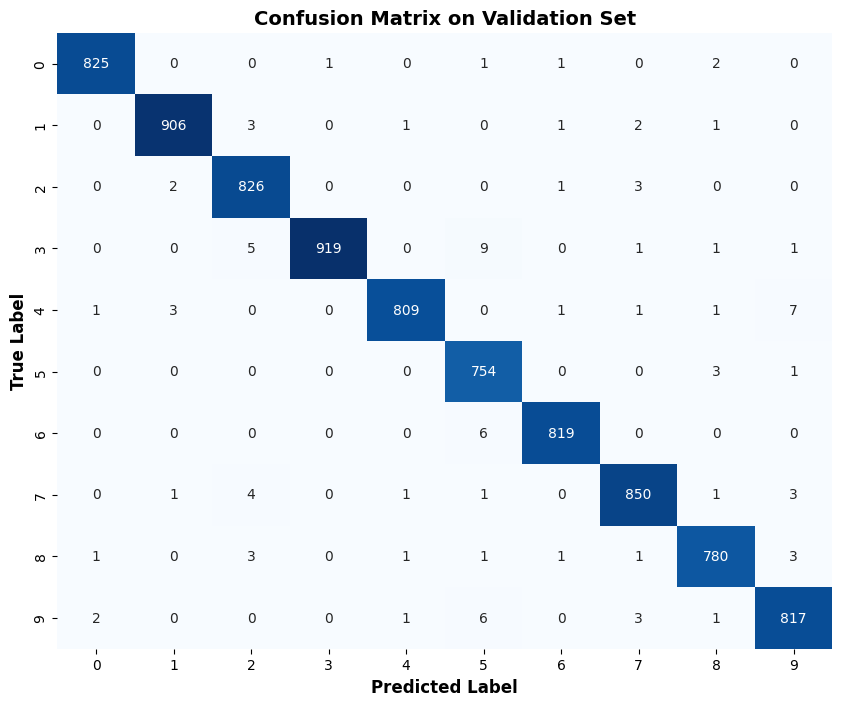

In [8]:
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from src.dataset import get_val_loader
from src.model import DigitCNN

# 1. Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DigitCNN().to(device)
model.load_state_dict(torch.load("../model/digit_cnn.pth", map_location=device))
model.eval()

# 2. Collect all predictions and true labels
val_loader = get_val_loader(csv_path="../data/digi_rec_train.csv", batch_size=128)
all_preds = []
all_labels = []
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Save misclassified images
        wrong_idx = (preds != labels).nonzero(as_tuple=True)[0]
        for idx in wrong_idx:
            if len(wrong_images) < 10:
                wrong_images.append(images[idx].cpu())
                wrong_preds.append(preds[idx].item())
                wrong_labels.append(labels[idx].item())

# 3. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix on Validation Set', fontsize=14, fontweight='bold')
plt.show()

Notice that some digit pairs are typically harder to distinguish than others! For example:
- 4 and 9 (they look very similar if the loop on the 9 is sloppy)
- 3 and 8 
- 1 and 7

Let's look at 10 examples where the model got it wrong!

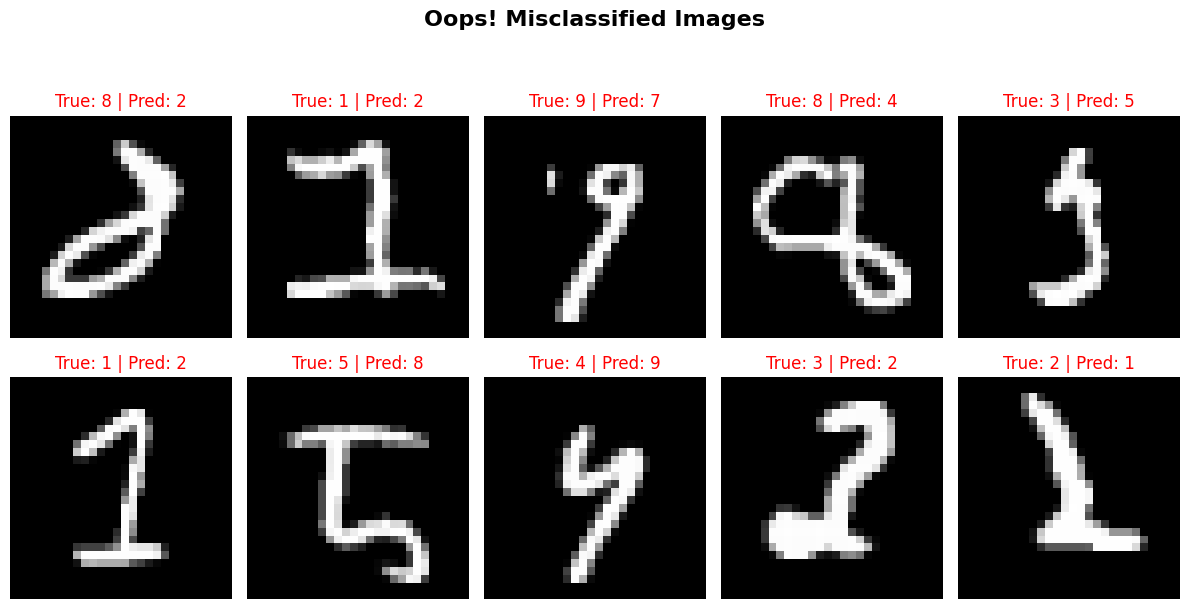

In [9]:
# Plot 10 images the model got wrong
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Oops! Misclassified Images", fontsize=16, fontweight='bold', y=1.05)

for i, ax in enumerate(axes.flat):
    if i < len(wrong_images):
        image_2d = wrong_images[i].squeeze().numpy()
        ax.imshow(image_2d, cmap='gray')
        ax.set_title(f"True: {wrong_labels[i]} | Pred: {wrong_preds[i]}", color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()